Shape of Dataset:
(1500, 8)

Number of Rows: 1500
Number of Columns: 8

Column Names:
['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours', 'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare']

First 10 Records:
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   
5        831.9           28.0          190.3               2.1      6.1   
6       1023.8           32.0          108.5               6.9      6.2   
7       1142.4           18.4          241.9               4.1      7.3   
8        810.4           36.4          164.8               9.9      6.5   
9       1085.

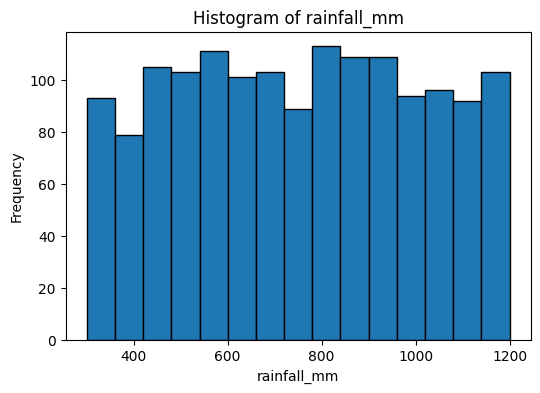

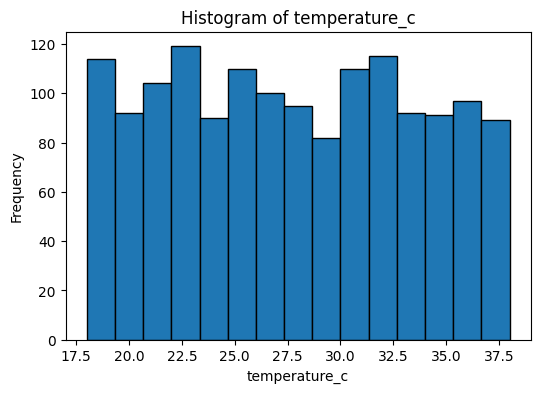

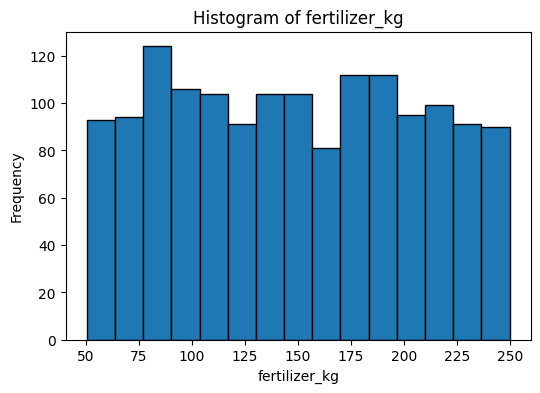

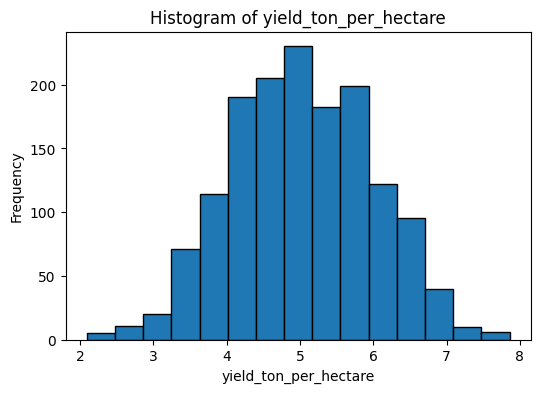


Crop Type Frequency:
crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


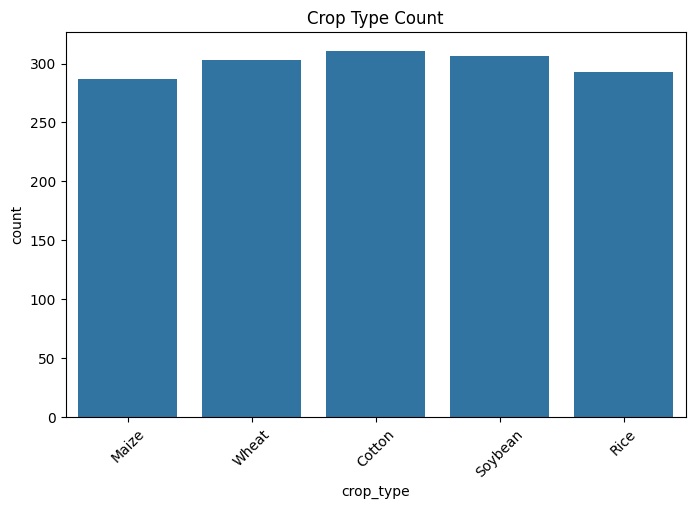


Most Frequent Crop Type:
Cotton

Soil Type Frequency:
soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


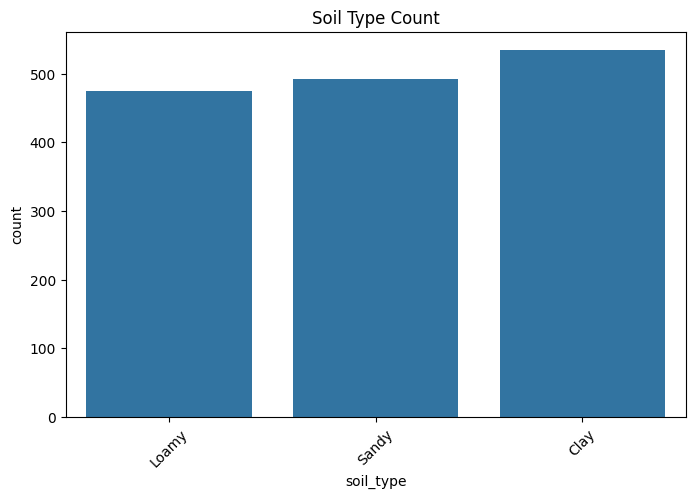


Most Common Soil Type:
Clay


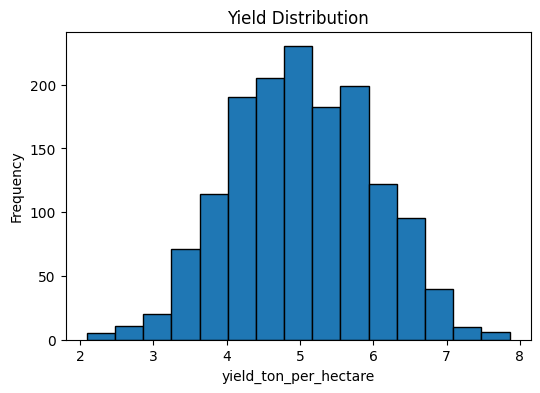

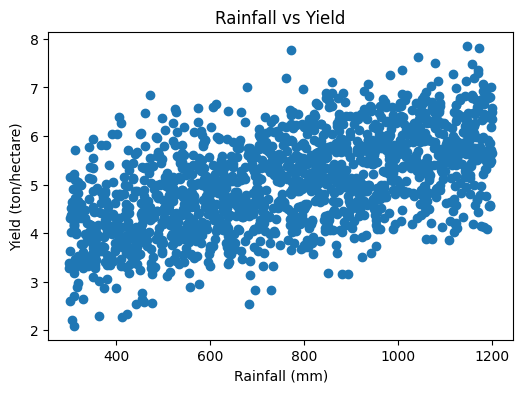

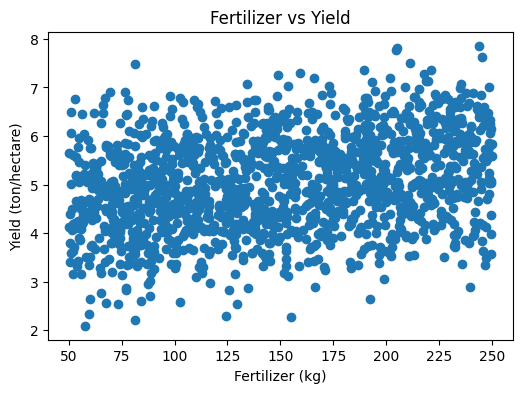

Correlation (Rainfall vs Yield): 0.5537042408932247
Correlation (Fertilizer vs Yield): 0.27804258886930494
Rainfall has a stronger relationship with yield.

Correlation Matrix:
                       rainfall_mm  temperature_c  fertilizer_kg  \
rainfall_mm               1.000000       0.026721       0.002558   
temperature_c             0.026721       1.000000       0.037468   
fertilizer_kg             0.002558       0.037468       1.000000   
irrigation_hours          0.010877       0.007114      -0.010497   
soil_ph                   0.006916       0.001513       0.010001   
yield_ton_per_hectare     0.553704      -0.022559       0.278043   

                       irrigation_hours   soil_ph  yield_ton_per_hectare  
rainfall_mm                    0.010877  0.006916               0.553704  
temperature_c                  0.007114  0.001513              -0.022559  
fertilizer_kg                 -0.010497  0.010001               0.278043  
irrigation_hours               1.000000  0.009

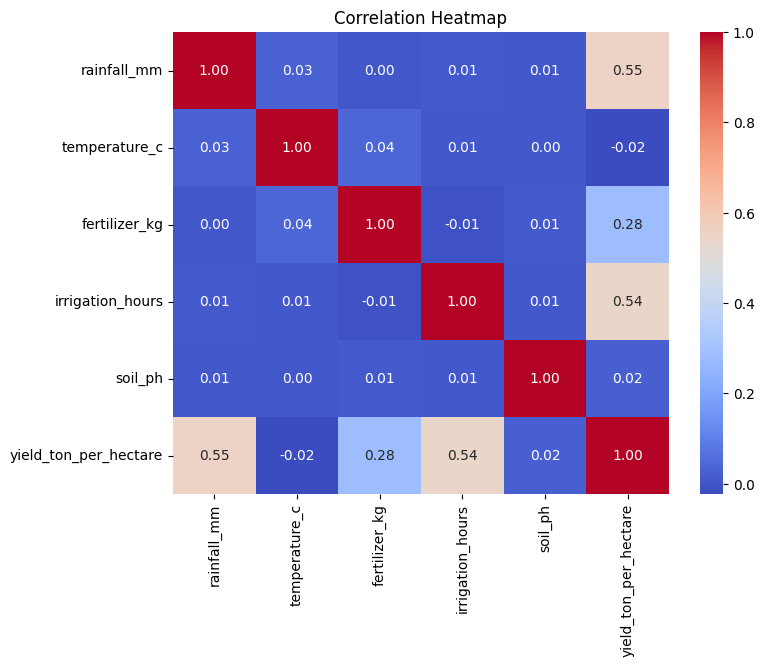


Top 3 Features Most Correlated with Yield:
rainfall_mm         0.553704
irrigation_hours    0.542664
fertilizer_kg       0.278043
Name: yield_ton_per_hectare, dtype: float64

Average Yield by Crop Type:
crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64

Average Yield by Soil Type:
soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64

Crop Type with Highest Average Yield:
Rice = 5.494744027303755

Soil Type with Highest Average Yield:
Loamy = 5.366518987341772

Categorical Columns:
['crop_type', 'soil_type']

First 5 Rows of Encoded Dataset:
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      

In [5]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("/content/agriculture_yield_dataset.csv")
# --------------------------------------------------
# Q1. Dataset Overview
# --------------------------------------------------

print("Shape of Dataset:")
print(df.shape)

print("\nNumber of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 10 Records:")
print(df.head(10))
# --------------------------------------------------
# Q2. Data Types and Missing Values
# --------------------------------------------------

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

missing_cols = df.columns[df.isnull().sum() > 0]
print("\nColumns with Missing Values:")
print(missing_cols.tolist())
# --------------------------------------------------
# Q3. Descriptive Statistics
# --------------------------------------------------

print("\nSummary Statistics:")
print(df.describe())

# Numerical columns only
numeric_cols = df.select_dtypes(include=['int64', 'float64'])

means = numeric_cols.mean()
stds = numeric_cols.std()

print("\nFeature with Highest Mean:")
print(means.idxmax(), "=", means.max())

print("\nFeature with Highest Standard Deviation:")
print(stds.idxmax(), "=", stds.max())
# --------------------------------------------------
# Q4. Distribution Analysis
# --------------------------------------------------

columns_to_plot = [
    'rainfall_mm',
    'temperature_c',
    'fertilizer_kg',
    'yield_ton_per_hectare'
]

for col in columns_to_plot:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=15, edgecolor='black')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()
# --------------------------------------------------
# Q5. Crop Type Analysis
# --------------------------------------------------

print("\nCrop Type Frequency:")
crop_counts = df['crop_type'].value_counts()
print(crop_counts)

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='crop_type')
plt.title("Crop Type Count")
plt.xticks(rotation=45)
plt.show()

print("\nMost Frequent Crop Type:")
print(crop_counts.idxmax())
# --------------------------------------------------
# Q6. Soil Type Analysis
# --------------------------------------------------

print("\nSoil Type Frequency:")
soil_counts = df['soil_type'].value_counts()
print(soil_counts)

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='soil_type')
plt.title("Soil Type Count")
plt.xticks(rotation=45)
plt.show()

print("\nMost Common Soil Type:")
print(soil_counts.idxmax())
# --------------------------------------------------
# Q7. Yield Distribution
# --------------------------------------------------

plt.figure(figsize=(6,4))
plt.hist(df['yield_ton_per_hectare'],
         bins=15,
         edgecolor='black')
plt.title('Yield Distribution')
plt.xlabel('yield_ton_per_hectare')
plt.ylabel('Frequency')
plt.show()
# --------------------------------------------------
# Q8. Scatter Plot Analysis
# --------------------------------------------------

plt.figure(figsize=(6,4))
plt.scatter(df['rainfall_mm'], df['yield_ton_per_hectare'])
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (ton/hectare)')
plt.title('Rainfall vs Yield')
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(df['fertilizer_kg'], df['yield_ton_per_hectare'])
plt.xlabel('Fertilizer (kg)')
plt.ylabel('Yield (ton/hectare)')
plt.title('Fertilizer vs Yield')
plt.show()

# Correlation with yield
corr_rainfall = df['rainfall_mm'].corr(df['yield_ton_per_hectare'])
corr_fertilizer = df['fertilizer_kg'].corr(df['yield_ton_per_hectare'])

print("Correlation (Rainfall vs Yield):", corr_rainfall)
print("Correlation (Fertilizer vs Yield):", corr_fertilizer)

if abs(corr_rainfall) > abs(corr_fertilizer):
    print("Rainfall has a stronger relationship with yield.")
else:
    print("Fertilizer has a stronger relationship with yield.")
# --------------------------------------------------
# Q9. Correlation Analysis
# --------------------------------------------------

numeric_df = df.select_dtypes(include=['int64', 'float64'])

corr_matrix = numeric_df.corr()

print("\nCorrelation Matrix:")
print(corr_matrix)

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# Top 3 features correlated with yield
yield_corr = corr_matrix['yield_ton_per_hectare'].drop('yield_ton_per_hectare')

top3 = yield_corr.abs().sort_values(ascending=False).head(3)

print("\nTop 3 Features Most Correlated with Yield:")
print(top3)
# --------------------------------------------------
# Q10. Group-Based Analysis
# --------------------------------------------------

crop_avg = df.groupby('crop_type')['yield_ton_per_hectare'].mean()

print("\nAverage Yield by Crop Type:")
print(crop_avg)

soil_avg = df.groupby('soil_type')['yield_ton_per_hectare'].mean()

print("\nAverage Yield by Soil Type:")
print(soil_avg)

print("\nCrop Type with Highest Average Yield:")
print(crop_avg.idxmax(), "=", crop_avg.max())

print("\nSoil Type with Highest Average Yield:")
print(soil_avg.idxmax(), "=", soil_avg.max())
# --------------------------------------------------
# Q11. Feature Encoding
# --------------------------------------------------

# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("\nCategorical Columns:")
print(categorical_cols.tolist())

# One-Hot Encoding
df_encoded = pd.get_dummies(df,
                            columns=categorical_cols,
                            drop_first=True)

print("\nFirst 5 Rows of Encoded Dataset:")
print(df_encoded.head())

print("\nShape of Encoded Dataset:")
print(df_encoded.shape)
# --------------------------------------------------
# Q12. Feature Selection
# --------------------------------------------------

# Target variable
y = df_encoded['yield_ton_per_hectare']

# Input features
X = df_encoded.drop('yield_ton_per_hectare', axis=1)

print("Target Variable (y): yield_ton_per_hectare")

print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

print("\nFirst 5 rows of X:")
print(X.head())

print("\nFirst 5 values of y:")
print(y.head())
# --------------------------------------------------
# Q13. Train-Test Split
# --------------------------------------------------

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining and Testing Shapes")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)
# --------------------------------------------------
# Q14. Linear Regression Model
# --------------------------------------------------

from sklearn.linear_model import LinearRegression

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

# Intercept
print("\nIntercept:")
print(model.intercept_)

# Coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print("\nModel Coefficients:")
print(coefficients)

# Feature with highest positive coefficient
highest_positive = coefficients.loc[
    coefficients['Coefficient'].idxmax()
]

print("\nFeature with Highest Positive Coefficient:")
print(highest_positive['Feature'])
print("Coefficient =", highest_positive['Coefficient'])